# SigLIP2 furniture training and retrieval playground

This notebook fine-tunes SigLIP2 on the validated 20,000-product furniture dataset, generates reusable image and description embeddings, and demonstrates three searches:

1. furniture image → 10 visually similar furniture images;
2. free text → 10 matching furniture images;
3. free text → 10 matching furniture descriptions.

The defaults are a bounded local smoke test. They train the two embedding heads and similarity calibration on 64 pairs, evaluate on 64 held-out pairs, and build a 250-product held-out search catalog.

## 0. Environment and experiment controls

Select the **RecSystem — SigLIP2 (Python 3.11)** kernel. Increase `CATALOG_ROWS` before scaling training so retrieval is judged against a more realistic candidate pool. Full-backbone training remains blocked unless CUDA is active.

In [1]:
from contextlib import nullcontext
from pathlib import Path
import json
import platform
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoProcessor

SEED = 42
MODEL_ID = "google/siglip2-base-patch16-224"
TRAINING_MODE = "heads"  # local default: heads; CUDA-only alternative: full
TRAIN_ROWS = 64
EVAL_ROWS = 64
CATALOG_ROWS = 250  # use None for the complete 2,000-row test catalog
EPOCHS = 1
TRAIN_BATCH_SIZE = 4
ENCODE_BATCH_SIZE = 4
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
RUN_TRAINING = True
LOAD_EXISTING_HEADS = False
SAVE_PLAYGROUND_ARTIFACTS = True
QUERY_ASIN = None  # None selects the first catalog product
TEXT_QUERY = "mid-century modern walnut coffee table for a living room"
TOP_K = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
PIN_MEMORY = DEVICE.type == "cuda"
print({
    "python": platform.python_version(),
    "executable": sys.executable,
    "device": str(DEVICE),
    "torch": torch.__version__,
})
if sys.version_info[:2] != (3, 11):
    raise RuntimeError("Select the RecSystem — SigLIP2 (Python 3.11) kernel.")
if TRAINING_MODE not in {"heads", "full"}:
    raise ValueError("TRAINING_MODE must be 'heads' or 'full'.")
if TRAINING_MODE == "full" and DEVICE.type != "cuda":
    raise RuntimeError("Full-backbone training is blocked locally. Use heads mode or move to CUDA.")

{'python': '3.11.6', 'executable': '/Users/vachemacbook/Desktop/RecSystem/RecSystem/.venv-siglip2/bin/python', 'device': 'mps', 'torch': '2.2.2'}


## 1. Load furniture pairs and create stable splits

The first run creates a deterministic 80/10/10 split, stratified by furniture subcategory. Later runs validate and reuse the saved ASIN-to-split mapping.

In [2]:
PAIRS_RELATIVE_PATH = Path("data/meta_Home_and_Kitchen_furniture_siglip2_pairs_20k.csv")
SPLIT_RELATIVE_PATH = Path("data/meta_Home_and_Kitchen_furniture_siglip2_splits_20k.csv")
REQUIRED_COLUMNS = ["asin", "description", "image_path"]
TAXONOMY_COLUMNS = ["furniture_subcategory", "category_path"]
CATALOG_COLUMNS = REQUIRED_COLUMNS + TAXONOMY_COLUMNS
EXPECTED_SPLITS = {"train": 16_000, "validation": 2_000, "test": 2_000}


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / PAIRS_RELATIVE_PATH).is_file():
            return candidate
    raise FileNotFoundError(f"Could not find {PAIRS_RELATIVE_PATH} from {start}")


def build_stratified_split_map(frame):
    all_indices = np.arange(len(frame))
    train_indices, held_out_indices = train_test_split(
        all_indices,
        test_size=0.20,
        random_state=SEED,
        stratify=frame["furniture_subcategory"],
    )
    validation_indices, test_indices = train_test_split(
        held_out_indices,
        test_size=0.50,
        random_state=SEED,
        stratify=frame.iloc[held_out_indices]["furniture_subcategory"],
    )
    split_values = np.empty(len(frame), dtype=object)
    split_values[train_indices] = "train"
    split_values[validation_indices] = "validation"
    split_values[test_indices] = "test"
    return pd.DataFrame({"asin": frame["asin"], "split": split_values})


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / "models/siglip2_furniture_playground"
HEAD_CHECKPOINT = ARTIFACT_DIR / "trained_heads.pt"
df = pd.read_csv(PROJECT_ROOT / PAIRS_RELATIVE_PATH, dtype="string")
missing_columns = set(CATALOG_COLUMNS) - set(df.columns)
if missing_columns:
    raise ValueError(f"Furniture pairs file is missing columns: {sorted(missing_columns)}")
for column in CATALOG_COLUMNS:
    df[column] = df[column].fillna("").str.strip()
df["image_file"] = df["image_path"].map(lambda path: PROJECT_ROOT / path)

split_path = PROJECT_ROOT / SPLIT_RELATIVE_PATH
if split_path.exists():
    split_map = pd.read_csv(split_path, dtype={"asin": "string", "split": "string"})
    print(f"Using existing split map: {split_path}")
else:
    split_map = build_stratified_split_map(df)
    split_map.to_csv(split_path, index=False)
    print(f"Saved stratified split map: {split_path}")

if split_map["asin"].duplicated().any() or set(split_map["asin"]) != set(df["asin"]):
    raise ValueError("Split map must contain each furniture ASIN exactly once.")
if split_map["split"].value_counts().to_dict() != EXPECTED_SPLITS:
    raise ValueError(f"Unexpected split counts: {split_map['split'].value_counts().to_dict()}")
df = df.merge(split_map, on="asin", validate="one_to_one")

quality = {
    "rows": len(df),
    "duplicate_asins": int(df["asin"].duplicated().sum()),
    "empty_descriptions": int(df["description"].eq("").sum()),
    "missing_images": int((~df["image_file"].map(Path.is_file)).sum()),
    "non_furniture_paths": int((~df["category_path"].str.startswith("Home & Kitchen > Furniture")).sum()),
    "splits": df["split"].value_counts().to_dict(),
}
print(quality)
expected_quality = {
    "rows": 20_000,
    "duplicate_asins": 0,
    "empty_descriptions": 0,
    "missing_images": 0,
    "non_furniture_paths": 0,
    "splits": EXPECTED_SPLITS,
}
if quality != expected_quality:
    raise ValueError(f"Unexpected furniture data quality: {quality}")

if TRAIN_ROWS > EXPECTED_SPLITS["train"] or EVAL_ROWS > EXPECTED_SPLITS["validation"]:
    raise ValueError("TRAIN_ROWS or EVAL_ROWS exceeds its split size.")
train_df = df[df["split"].eq("train")].sample(n=TRAIN_ROWS, random_state=SEED).reset_index(drop=True)
eval_df = df[df["split"].eq("validation")].sample(n=EVAL_ROWS, random_state=SEED).reset_index(drop=True)
test_pool = df[df["split"].eq("test")].reset_index(drop=True)
catalog_df = (
    test_pool
    if CATALOG_ROWS is None
    else test_pool.sample(n=CATALOG_ROWS, random_state=SEED).reset_index(drop=True)
)
print({
    "training_pairs": len(train_df),
    "evaluation_pairs": len(eval_df),
    "catalog_products": len(catalog_df),
})
display(df.groupby(["split", "furniture_subcategory"]).size().unstack(fill_value=0))

Using existing split map: /Users/vachemacbook/Desktop/RecSystem/RecSystem/data/meta_Home_and_Kitchen_furniture_siglip2_splits_20k.csv


{'rows': 20000, 'duplicate_asins': 0, 'empty_descriptions': 0, 'missing_images': 0, 'non_furniture_paths': 0, 'splits': {'train': 16000, 'validation': 2000, 'test': 2000}}
{'training_pairs': 64, 'evaluation_pairs': 64, 'catalog_products': 250}


furniture_subcategory,Accent Furniture,Bathroom Furniture,Bedroom Furniture,Dining Room Furniture,Entryway Furniture,Game & Recreation Room Furniture,Home Office Furniture,Kids' Furniture,Kitchen Furniture,Living Room Furniture,Replacement Parts,Unspecified
split,,,,,,,,,,,,
test,36,9,408,205,39,197,234,83,22,695,20,52
train,292,70,3271,1637,311,1570,1868,666,180,5559,158,418
validation,37,9,409,204,39,196,233,83,23,695,20,52


## 2. Processor, paired dataset, and loaders

In [3]:
MAX_TEXT_LENGTH = 64
NUM_WORKERS = 0
processor = AutoProcessor.from_pretrained(MODEL_ID)


def open_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB")


class FurniturePairs(Dataset):
    def __init__(self, frame):
        self.records = frame[["asin", "description", "image_file"]].to_dict("records")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[index]
        return {
            "asin": row["asin"],
            "text": row["description"],
            "image": open_rgb(row["image_file"]),
        }


def collate_pairs(examples):
    batch = processor(
        text=[example["text"] for example in examples],
        images=[example["image"] for example in examples],
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt",
    )
    batch["asins"] = [example["asin"] for example in examples]
    return batch


def make_loader(frame, batch_size, *, shuffle=False):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        FurniturePairs(frame),
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        collate_fn=collate_pairs,
        drop_last=False,
    )


train_loader = make_loader(train_df, TRAIN_BATCH_SIZE, shuffle=True)
eval_loader = make_loader(eval_df, ENCODE_BATCH_SIZE)
catalog_loader = make_loader(catalog_df, ENCODE_BATCH_SIZE)
sample_batch = next(iter(train_loader))
print({key: tuple(value.shape) for key, value in sample_batch.items() if key != "asins"})

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


{'pixel_values': (4, 3, 224, 224), 'input_ids': (4, 64)}


## 3. Load SigLIP2 and choose trainable parameters

`heads` freezes both 12-layer transformer backbones and trains the text projection head, vision attention-pooling head, and learned logit scale/bias. This changes both final embedding representations while keeping local memory use manageable.

In [4]:
model = AutoModel.from_pretrained(MODEL_ID).to(DEVICE)


def configure_trainable_parameters(model, mode):
    for parameter in model.parameters():
        parameter.requires_grad = mode == "full"
    if mode == "heads":
        for module in (model.text_model.head, model.vision_model.head):
            for parameter in module.parameters():
                parameter.requires_grad = True
        model.logit_scale.requires_grad = True
        model.logit_bias.requires_grad = True
    return [name for name, parameter in model.named_parameters() if parameter.requires_grad]


trainable_names = configure_trainable_parameters(model, TRAINING_MODE)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
print({
    "model_class": model.__class__.__name__,
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
    "trainable_percent": round(100 * trainable_parameters / total_parameters, 3),
    "training_mode": TRAINING_MODE,
})

if LOAD_EXISTING_HEADS:
    if not HEAD_CHECKPOINT.is_file():
        raise FileNotFoundError(f"Furniture head checkpoint not found: {HEAD_CHECKPOINT}")
    saved_state = torch.load(HEAD_CHECKPOINT, map_location=DEVICE)
    load_result = model.load_state_dict(saved_state, strict=False)
    if load_result.unexpected_keys:
        raise ValueError(f"Unexpected checkpoint keys: {load_result.unexpected_keys}")
    print(f"Loaded {len(saved_state)} trained tensors from {HEAD_CHECKPOINT}.")

{'model_class': 'SiglipModel', 'total_parameters': 375187970, 'trainable_parameters': 7677698, 'trainable_percent': 2.046, 'training_mode': 'heads'}


## 4. Baseline evaluation before training

Paired bidirectional Recall@K is a plumbing metric: each row has one recorded positive even though several furniture products may be valid semantic matches.

In [5]:
def move_tensors(batch):
    return {
        key: value.to(DEVICE, non_blocking=PIN_MEMORY)
        for key, value in batch.items()
        if key != "asins"
    }


def encode_pairs(loader, description):
    all_asins, image_chunks, text_chunks = [], [], []
    model.eval()
    with torch.inference_mode():
        for batch in tqdm(loader, desc=description):
            all_asins.extend(batch["asins"])
            outputs = model(**move_tensors(batch), return_dict=True)
            image_chunks.append(F.normalize(outputs.image_embeds, dim=-1).cpu())
            text_chunks.append(F.normalize(outputs.text_embeds, dim=-1).cpu())
    return all_asins, torch.cat(image_chunks), torch.cat(text_chunks)


def paired_recall(image_embeddings, text_embeddings, ks=(1, 5, 10)):
    similarities = image_embeddings @ text_embeddings.T
    targets = torch.arange(len(similarities))
    image_ranked = similarities.argsort(dim=1, descending=True)
    text_ranked = similarities.T.argsort(dim=1, descending=True)
    metrics = {}
    for k in ks:
        effective_k = min(k, len(similarities))
        metrics[f"image_to_text_recall@{k}"] = (
            (image_ranked[:, :effective_k] == targets[:, None]).any(1).float().mean().item()
        )
        metrics[f"text_to_image_recall@{k}"] = (
            (text_ranked[:, :effective_k] == targets[:, None]).any(1).float().mean().item()
        )
    return metrics


eval_asins, baseline_eval_images, baseline_eval_texts = encode_pairs(
    eval_loader, "Baseline furniture evaluation"
)
baseline_metrics = paired_recall(baseline_eval_images, baseline_eval_texts)
display(pd.Series(baseline_metrics, name="before_training").to_frame())

Baseline furniture evaluation:   0%|          | 0/16 [00:00<?, ?it/s]

,before_training
image_to_text_recall@1,0.546875
text_to_image_recall@1,0.500000
image_to_text_recall@5,0.671875
text_to_image_recall@5,0.703125
image_to_text_recall@10,0.765625
text_to_image_recall@10,0.781250


## 5. Train on aligned furniture image-description pairs

SigLIP's sigmoid contrastive loss treats matching diagonal pairs as positives and the other pairs in each batch as negatives. Batch size four is deliberately conservative for this local machine.

In [6]:
training_history = []
if RUN_TRAINING:
    optimizer = torch.optim.AdamW(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    started_at = time.perf_counter()
    for epoch in range(EPOCHS):
        model.train()
        epoch_losses = []
        for batch in tqdm(train_loader, desc=f"Training epoch {epoch + 1}"):
            optimizer.zero_grad(set_to_none=True)
            autocast_context = (
                torch.autocast("cuda", dtype=torch.float16)
                if use_amp else nullcontext()
            )
            with autocast_context:
                loss = model(**move_tensors(batch), return_loss=True, return_dict=True).loss
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite training loss: {loss.item()}")
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [parameter for parameter in model.parameters() if parameter.requires_grad],
                MAX_GRAD_NORM,
            )
            scaler.step(optimizer)
            scaler.update()
            epoch_losses.append(loss.item())
        training_history.append({
            "epoch": epoch + 1,
            "mean_loss": float(np.mean(epoch_losses)),
            "first_loss": float(epoch_losses[0]),
            "last_loss": float(epoch_losses[-1]),
        })
    elapsed_seconds = time.perf_counter() - started_at
    model.eval()
    print({"history": training_history, "elapsed_seconds": round(elapsed_seconds, 1)})
else:
    print("Training skipped; retrieval will use the pretrained or loaded-head model.")

Training epoch 1:   0%|          | 0/16 [00:00<?, ?it/s]

{'history': [{'epoch': 1, 'mean_loss': 3.908190470188856, 'first_loss': 2.8229360580444336, 'last_loss': 1.6853618621826172}], 'elapsed_seconds': 5.8}


In [7]:
_, trained_eval_images, trained_eval_texts = encode_pairs(
    eval_loader, "Post-training furniture evaluation"
)
trained_metrics = paired_recall(trained_eval_images, trained_eval_texts)
comparison = pd.DataFrame({
    "before_training": baseline_metrics,
    "after_training": trained_metrics,
})
comparison["change"] = comparison["after_training"] - comparison["before_training"]
display(comparison)

Post-training furniture evaluation:   0%|          | 0/16 [00:00<?, ?it/s]

,before_training,after_training,change
image_to_text_recall@1,0.546875,0.515625,-0.031250
text_to_image_recall@1,0.500000,0.515625,0.015625
image_to_text_recall@5,0.671875,0.718750,0.046875
text_to_image_recall@5,0.703125,0.703125,0.000000
image_to_text_recall@10,0.765625,0.781250,0.015625
text_to_image_recall@10,0.781250,0.765625,-0.015625


## 6. Generate the held-out furniture embedding catalog

Image and description matrices use identical row order, are L2-normalized, and align with `embedding_catalog.csv`. Cosine similarity is therefore a matrix-vector dot product.

In [8]:
catalog_asins, image_embeddings, description_embeddings = encode_pairs(
    catalog_loader, "Embedding furniture catalog"
)
catalog_index = catalog_df.set_index("asin").loc[catalog_asins].reset_index()
if len(catalog_index) != len(image_embeddings) or image_embeddings.shape != description_embeddings.shape:
    raise ValueError("Catalog rows and embedding matrices lost alignment.")
print({
    "catalog_rows": len(catalog_index),
    "image_embeddings": tuple(image_embeddings.shape),
    "description_embeddings": tuple(description_embeddings.shape),
    "image_norm_mean": image_embeddings.norm(dim=1).mean().item(),
    "description_norm_mean": description_embeddings.norm(dim=1).mean().item(),
})

Embedding furniture catalog:   0%|          | 0/63 [00:00<?, ?it/s]

{'catalog_rows': 250, 'image_embeddings': (250, 768), 'description_embeddings': (250, 768), 'image_norm_mean': 1.0, 'description_norm_mean': 1.0}


## 7. Retrieval helpers and three playground scenarios

In [9]:
def ranked_results(scores, k=TOP_K, exclude_index=None):
    scores = scores.clone()
    if exclude_index is not None:
        scores[exclude_index] = -torch.inf
    result_count = min(k, len(scores) - (exclude_index is not None))
    values, indices = scores.topk(result_count)
    results = catalog_index.iloc[indices.tolist()][CATALOG_COLUMNS].copy()
    results.insert(1, "score", values.numpy())
    return results.reset_index(drop=True)


def show_product_grid(results, title, columns=5):
    rows = int(np.ceil(len(results) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(3.3 * columns, 3.6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, row in zip(axes, results.itertuples()):
        ax.imshow(open_rgb(PROJECT_ROOT / row.image_path))
        ax.set_title(
            f"{row.asin} | {row.score:.3f}\n{row.furniture_subcategory}\n{row.description[:45]}",
            fontsize=8,
        )
        ax.axis("off")
    for ax in axes[len(results):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig


def embed_text(query):
    inputs = processor(
        text=[query],
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt",
    )
    with torch.inference_mode():
        embedding = model.get_text_features(
            **{key: value.to(DEVICE) for key, value in inputs.items()}
        )
    return F.normalize(embedding, dim=-1).cpu()[0]


def search_by_image(asin, k=TOP_K):
    matches = catalog_index.index[catalog_index["asin"].eq(asin)].tolist()
    if not matches:
        raise KeyError(f"ASIN {asin} is not in this {len(catalog_index)}-product catalog.")
    query_index = matches[0]
    scores = image_embeddings @ image_embeddings[query_index]
    return catalog_index.iloc[query_index], ranked_results(
        scores, k=k, exclude_index=query_index
    )


def search_by_text(query, target="images", k=TOP_K):
    query_embedding = embed_text(query)
    if target not in {"images", "descriptions"}:
        raise ValueError("target must be 'images' or 'descriptions'.")
    target_embeddings = image_embeddings if target == "images" else description_embeddings
    return ranked_results(target_embeddings @ query_embedding, k=k)

### Scenario A — furniture image → top 10 similar images

Query product: B0057GFHTQ | Living Room Furniture — Ottomans is a great idea for your living room.


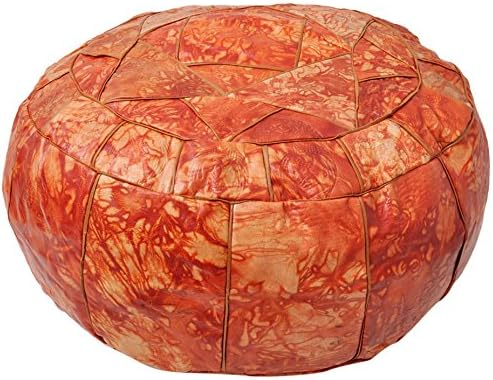

,asin,score,description,image_path,furniture_subcategory,category_path
0,B01GC4SMFC,0.859933,This lovely Moroccan pouf is crafted to perfec...,data/images_furniture/B01GC4SMFC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
1,B01N5PT9LA,0.781549,"Moroccan Leather Poufs, known for bringing ele...",data/images_furniture/B01N5PT9LA.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
2,B01D9V47KK,0.766664,This Sodynee Faux Leather Folding Shoe Storage...,data/images_furniture/B01D9V47KK.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
3,B08NRQ9FHM,0.758303,Invite elevating colors and textures into your...,data/images_furniture/B08NRQ9FHM.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
4,B01F7CF1D6,0.728450,Why Choose Collapsible Folding Storage Ottoman...,data/images_furniture/B01F7CF1D6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
5,B075QDX4SP,0.724616,Description This is our Giantex storage bench ...,data/images_furniture/B075QDX4SP.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
6,B09TTBX11K,0.718851,Notice: The product is just a sofa cover witho...,data/images_furniture/B09TTBX11K.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
7,B07NSGPZ64,0.710449,Crosshatch patterning and a gold-tone finish p...,data/images_furniture/B07NSGPZ64.jpg,Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...
8,B086X52YN6,0.703143,"Specification: Color: Grey Material: Sponge, P...",data/images_furniture/B086X52YN6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
9,B00OBAL4XW,0.701560,"Sandy Wilson, Brown Jacobean Storage Vanity St...",data/images_furniture/B00OBAL4XW.jpg,Unspecified,Home & Kitchen > Furniture


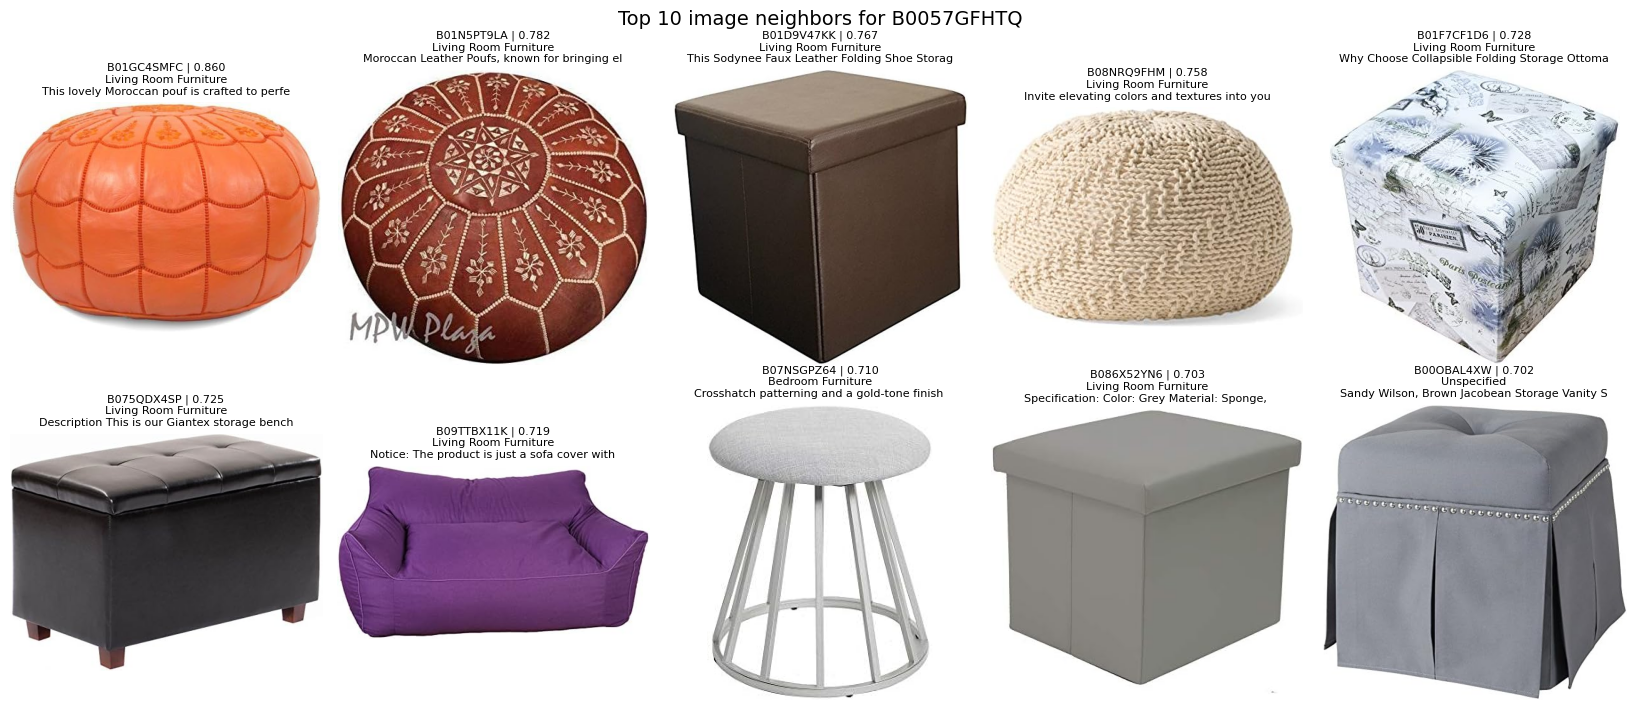

In [10]:
selected_asin = QUERY_ASIN or catalog_index.iloc[0]["asin"]
query_product, image_results = search_by_image(selected_asin)
print(
    "Query product:", query_product["asin"],
    "|", query_product["furniture_subcategory"],
    "—", query_product["description"][:180],
)
display(open_rgb(PROJECT_ROOT / query_product["image_path"]))
display(image_results)
show_product_grid(image_results, f"Top {TOP_K} image neighbors for {selected_asin}");

### Scenario B — free text → top 10 matching furniture images

The query uses SigLIP2's text tower and is compared directly with stored furniture image embeddings.

Text query: mid-century modern walnut coffee table for a living room


,asin,score,description,image_path,furniture_subcategory,category_path
0,B08SSDJ8TC,0.169808,Sensational and simple this rectangle coffee t...,data/images_furniture/B08SSDJ8TC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
1,B007U3LBGW,0.145739,The Clemson collection balances style and vers...,data/images_furniture/B007U3LBGW.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
2,B07XB1P8Q6,0.138422,Description Overall Dimension: 31.5“L x 31.5”W...,data/images_furniture/B07XB1P8Q6.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
3,B01FXYB86M,0.130937,Looking for a rustic contemporary Coffee Table...,data/images_furniture/B01FXYB86M.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
4,B075TYWK2H,0.119121,Create a modern minimalist aesthetic in your k...,data/images_furniture/B075TYWK2H.jpg,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
5,B01MZ4G2HJ,0.118590,Lane Home Furnishings oval end table with gran...,data/images_furniture/B01MZ4G2HJ.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
6,B004S9JSUW,0.105493,"Clean lines, minimal embellishment and underst...",data/images_furniture/B004S9JSUW.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
7,B085BRP7CL,0.098866,Nesting Table Round Glass Coffee Table 2 Piece...,data/images_furniture/B085BRP7CL.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
8,B07VR963ZD,0.096644,EAST WEST FURNITURE - LYT-ESP-T - LYNFIELD MID...,data/images_furniture/B07VR963ZD.jpg,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
9,B076GXZ8QC,0.094320,Furnish your living room with this classic che...,data/images_furniture/B076GXZ8QC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...


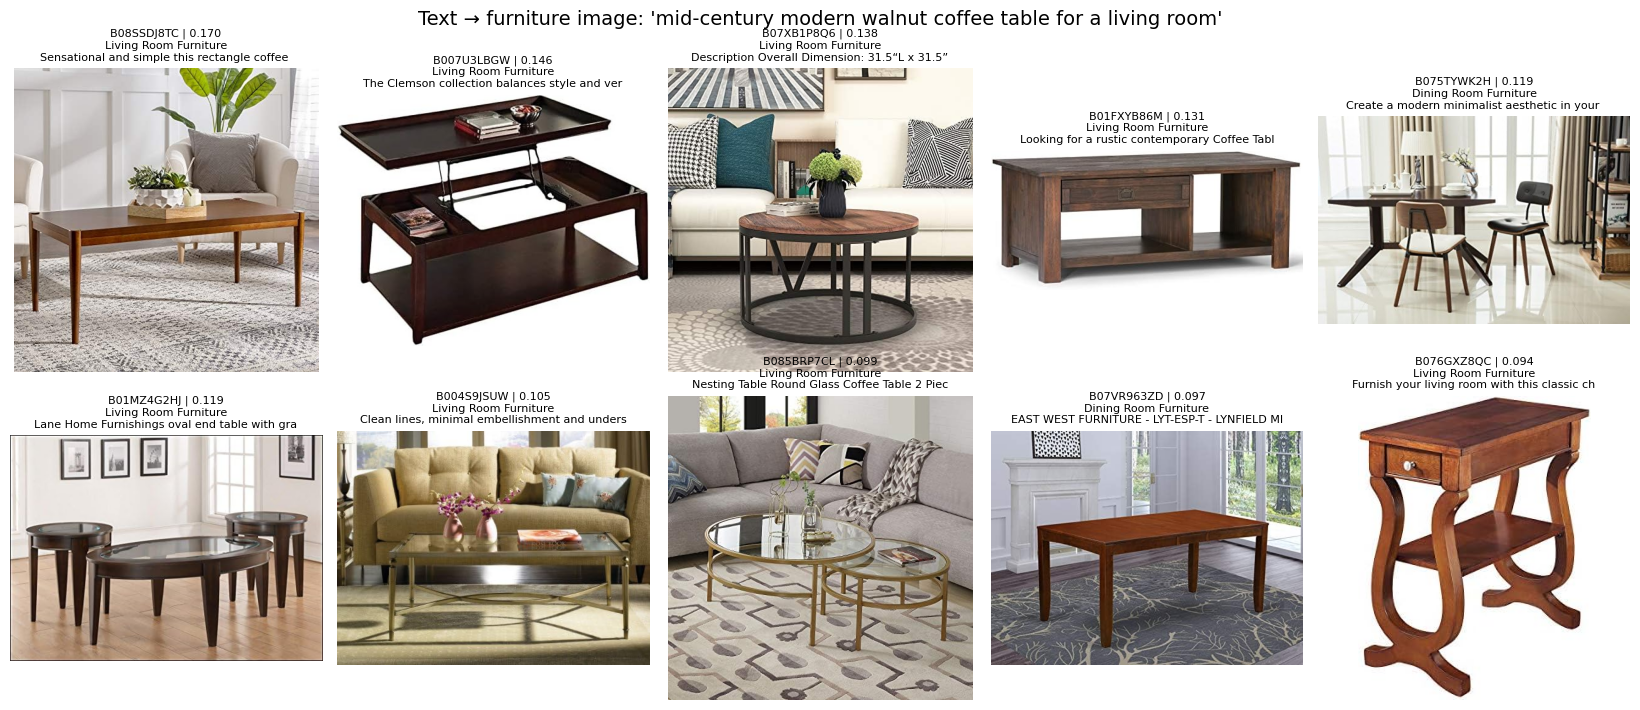

In [11]:
text_to_image_results = search_by_text(TEXT_QUERY, target="images")
print("Text query:", TEXT_QUERY)
display(text_to_image_results)
show_product_grid(text_to_image_results, f"Text → furniture image: {TEXT_QUERY!r}");

### Scenario C — free text → top 10 matching furniture descriptions

This compares the query with stored description embeddings and behaves more like semantic catalog search.

,asin,score,description,image_path,furniture_subcategory,category_path
0,B01I5HHDM2,0.799920,The Lucerne dining table is made with 80 year ...,data/images_furniture/B01I5HHDM2.jpg,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
1,B08SSDJ8TC,0.791816,Sensational and simple this rectangle coffee t...,data/images_furniture/B08SSDJ8TC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
2,B0BZCZNLCD,0.789512,Description: If you need a sturdy and versatil...,data/images_furniture/B0BZCZNLCD.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
3,B076GXZ8QC,0.787925,Furnish your living room with this classic che...,data/images_furniture/B076GXZ8QC.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
4,B01MZ4G2HJ,0.776569,Lane Home Furnishings oval end table with gran...,data/images_furniture/B01MZ4G2HJ.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
5,B07KY5HVGF,0.772821,This metal end table set is the perfect pair o...,data/images_furniture/B07KY5HVGF.jpg,Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...
6,B01MQVAVKV,0.770101,The Beloit C table is a versatile piece that c...,data/images_furniture/B01MQVAVKV.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
7,B0057GFHTQ,0.757823,Ottomans is a great idea for your living room.,data/images_furniture/B0057GFHTQ.jpg,Living Room Furniture,Home & Kitchen > Furniture > Living Room Furni...
8,B0952SP78Q,0.757140,"This dining table, designed with clean and sim...",data/images_furniture/B0952SP78Q.jpg,Dining Room Furniture,Home & Kitchen > Furniture > Dining Room Furni...
9,B0043SSNP4,0.756159,"The ""Timberline"" bedroom collection grasps the...",data/images_furniture/B0043SSNP4.jpg,Bedroom Furniture,Home & Kitchen > Furniture > Bedroom Furniture...


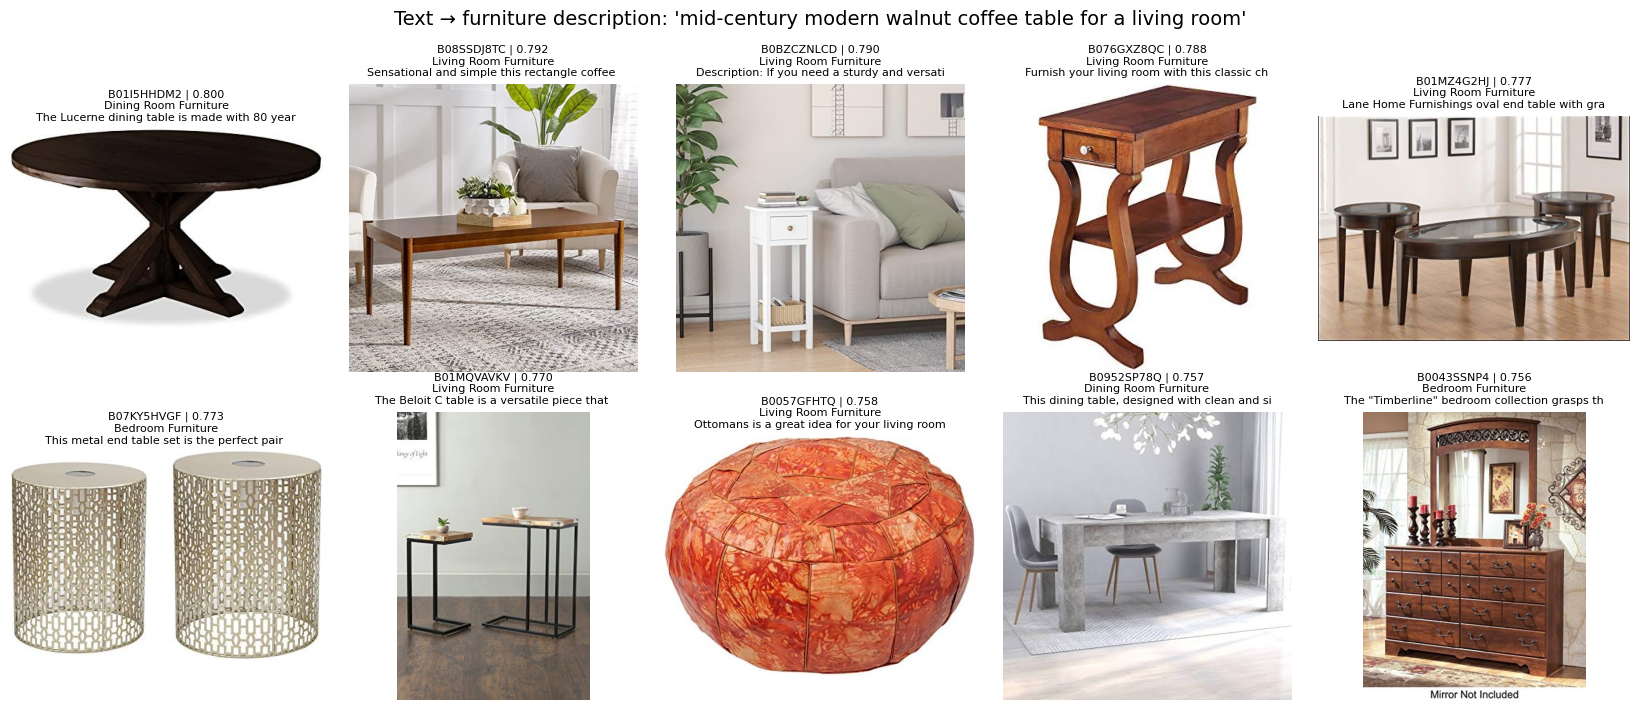

In [12]:
text_to_description_results = search_by_text(TEXT_QUERY, target="descriptions")
display(text_to_description_results)
show_product_grid(
    text_to_description_results,
    f"Text → furniture description: {TEXT_QUERY!r}",
);

## 8. Save furniture-trained heads and reusable embeddings

The partial head checkpoint is applied on top of the original Hugging Face checkpoint. The catalog CSV and both NumPy matrices share exact row order.

In [13]:
if SAVE_PLAYGROUND_ARTIFACTS:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    if RUN_TRAINING:
        trainable_state = {
            name: parameter.detach().cpu()
            for name, parameter in model.named_parameters()
            if name in trainable_names
        }
        torch.save(trainable_state, HEAD_CHECKPOINT)
    elif not LOAD_EXISTING_HEADS:
        print("No furniture head checkpoint written because training and loading were disabled.")
    np.save(ARTIFACT_DIR / "image_embeddings.npy", image_embeddings.numpy())
    np.save(
        ARTIFACT_DIR / "description_embeddings.npy",
        description_embeddings.numpy(),
    )
    catalog_index[CATALOG_COLUMNS].to_csv(
        ARTIFACT_DIR / "embedding_catalog.csv", index=False
    )
    with (ARTIFACT_DIR / "experiment.json").open("w") as file:
        json.dump({
            "model_id": MODEL_ID,
            "dataset": str(PAIRS_RELATIVE_PATH),
            "split_map": str(SPLIT_RELATIVE_PATH),
            "training_mode": TRAINING_MODE,
            "train_rows": len(train_df),
            "evaluation_rows": len(eval_df),
            "catalog_rows": len(catalog_index),
            "epochs": EPOCHS,
            "learning_rate": LEARNING_RATE,
            "training_history": training_history,
            "baseline_metrics": baseline_metrics,
            "trained_metrics": trained_metrics,
        }, file, indent=2)
    print("Saved:", sorted(path.name for path in ARTIFACT_DIR.iterdir()))
    print("Furniture artifact directory:", ARTIFACT_DIR.resolve())
else:
    print("Artifact saving disabled.")

Saved: ['description_embeddings.npy', 'embedding_catalog.csv', 'experiment.json', 'image_embeddings.npy', 'trained_heads.pt']
Furniture artifact directory: /Users/vachemacbook/Desktop/RecSystem/RecSystem/models/siglip2_furniture_playground


## How to play with this safely

- Change `TEXT_QUERY` and rerun the two text-search cells; catalog re-embedding is unnecessary.
- Set `QUERY_ASIN` to an ASIN from `catalog_index`, then rerun the image-search cell.
- Set `CATALOG_ROWS=None` to search the complete 2,000-product test catalog.
- Increase `TRAIN_ROWS` gradually on this laptop and watch memory and elapsed time.
- Compare before/after Recall@K, but do not over-interpret 64 pairs or one epoch.
- For serious tuning, use CUDA, larger in-batch negatives, duplicate-aware grouping, and multiple learning-rate runs.
- This retrieves substitutes and semantically related furniture. Complementary recommendations still require interaction or co-purchase data and a ranking objective.